# Materi 4 :Representasi Kalimat Menjadi Vektor Menggunakan Skipgram (Gensim)

In [1]:
!pip install gensim
import gensim
from gensim.models import Word2Vec
import numpy as np
import string

kalimat = [
    "Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026.",
    "Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan dilakukan.",
    "Perbasi merilis roster Timnas Basket 3x3 Putri Indonesia yang akan berlaga di Asian Games 2026."
]

kalimat_bersih = [k.lower().translate(str.maketrans('', '', string.punctuation)) for k in kalimat]

tokenized_kalimat = [k.split() for k in kalimat_bersih]
print("Kumpulan kata (token):")
for i, token in enumerate(tokenized_kalimat):
    print(f"Kalimat {i+1}: {token}")

Kumpulan kata (token):
Kalimat 1: ['timnas', 'basket', 'putra', 'indonesia', 'gagal', 'melaju', 'ke', 'perempatfinal', 'asian', 'games', '2026']
Kalimat 2: ['pelatih', 'david', 'singleton', 'menyebut', 'hasil', 'tersebut', 'sebagai', 'kegagalan', 'dan', 'menegaskan', 'evaluasi', 'menyeluruh', 'akan', 'dilakukan']
Kalimat 3: ['perbasi', 'merilis', 'roster', 'timnas', 'basket', '3x3', 'putri', 'indonesia', 'yang', 'akan', 'berlaga', 'di', 'asian', 'games', '2026']


In [2]:
# 3. Membuat model Word2Vec dengan arsitektur Skipgram (sg=1)
model_skipgram = Word2Vec(sentences=tokenized_kalimat, vector_size=10, window=5, min_count=1, sg=1)

print("Model Word2Vec Skipgram berhasil dibuat!")

Model Word2Vec Skipgram berhasil dibuat!


In [3]:
# 4. Representasikan 3 kalimat tersebut menjadi vektor
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

print("Representasi Vektor untuk masing-masing kalimat:\n")
for i, token in enumerate(tokenized_kalimat):
    vec = sentence_vector(token, model_skipgram)
    print(f"Kalimat {i+1}: '{kalimat[i]}'")
    print(f"Vektor:\n{vec}\n")

Representasi Vektor untuk masing-masing kalimat:

Kalimat 1: 'Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026.'
Vektor:
[-0.01158784  0.01953103  0.00817843 -0.01299747  0.01690444 -0.01240175
  0.02266861  0.00719794 -0.00059926 -0.00398721]

Kalimat 2: 'Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan dilakukan.'
Vektor:
[-0.01098954 -0.01744286  0.0062532  -0.00683713 -0.00718443  0.0083017
  0.03428303  0.01317212 -0.03038973  0.00854018]

Kalimat 3: 'Perbasi merilis roster Timnas Basket 3x3 Putri Indonesia yang akan berlaga di Asian Games 2026.'
Vektor:
[ 0.00304488  0.0023237   0.00367716 -0.00483525  0.01558923  0.00361649
  0.02198086  0.01880474 -0.01628652  0.00965468]



## Hasil Detail: Analisis Representasi Skip-gram

Model di atas dibuat ulang dengan `seed=42` supaya hasilnya bisa direproduksi
(model di bagian awal tidak pakai seed sehingga tiap eksekusi angkanya beda).

- **Hasil A** - Tokenisasi: jumlah token tiap kalimat & kosakata unik yang dipelajari
- **Hasil B** - Vektor tiap kalimat (10 dimensi) + norma vektor
- **Hasil C** - Kesamaan antar kalimat (cosine similarity 3x3)
- **Hasil D** - Kata paling mirip dengan kata tertentu & catatan perbandingan dengan aplikasi

In [4]:
import string
import pandas as pd

kalimat = [
    "Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026.",
    "Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan dilakukan.",
    "Perbasi merilis roster Timnas Basket 3x3 Putri Indonesia yang akan berlaga di Asian Games 2026."
]

kalimat_bersih = [k.lower().translate(str.maketrans("", "", string.punctuation)) for k in kalimat]
tokenized_kalimat = [k.split() for k in kalimat_bersih]

print("=" * 72)
print("HASIL A : Tokenisasi & kosakata")
print("=" * 72)
for i, token in enumerate(tokenized_kalimat):
    print(f"Kalimat {i + 1} ({len(token)} token): {token}")

semua_kata = [w for t in tokenized_kalimat for w in t]
kosakata = sorted(set(semua_kata))
print(f"\nTotal token seluruh kalimat : {len(semua_kata)}")
print(f"Jumlah kata unik            : {len(kosakata)}")
print(f"Kosakata                    : {kosakata}")
print("\nFrekuensi tiap kata:")
print(pd.Series(semua_kata).value_counts().rename_axis("Kata").to_frame("Frekuensi").to_string())

HASIL A : Tokenisasi & kosakata
Kalimat 1 (11 token): ['timnas', 'basket', 'putra', 'indonesia', 'gagal', 'melaju', 'ke', 'perempatfinal', 'asian', 'games', '2026']
Kalimat 2 (14 token): ['pelatih', 'david', 'singleton', 'menyebut', 'hasil', 'tersebut', 'sebagai', 'kegagalan', 'dan', 'menegaskan', 'evaluasi', 'menyeluruh', 'akan', 'dilakukan']
Kalimat 3 (15 token): ['perbasi', 'merilis', 'roster', 'timnas', 'basket', '3x3', 'putri', 'indonesia', 'yang', 'akan', 'berlaga', 'di', 'asian', 'games', '2026']

Total token seluruh kalimat : 40
Jumlah kata unik            : 33
Kosakata                    : ['2026', '3x3', 'akan', 'asian', 'basket', 'berlaga', 'dan', 'david', 'di', 'dilakukan', 'evaluasi', 'gagal', 'games', 'hasil', 'indonesia', 'ke', 'kegagalan', 'melaju', 'menegaskan', 'menyebut', 'menyeluruh', 'merilis', 'pelatih', 'perbasi', 'perempatfinal', 'putra', 'putri', 'roster', 'sebagai', 'singleton', 'tersebut', 'timnas', 'yang']

Frekuensi tiap kata:
               Frekuensi
Kata 

In [5]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec

model_skipgram = Word2Vec(sentences=tokenized_kalimat, vector_size=10, window=5,
                          min_count=1, sg=1, seed=42)

def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

print("=" * 72)
print("HASIL B : Vektor kalimat (Skip-gram, vector_size=10, window=5, sg=1)")
print("=" * 72)
print(f"Ukuran kosakata model : {len(model_skipgram.wv)} kata")
print(f"Dimensi vektor         : {model_skipgram.vector_size}")
print(f"Parameter lain         : window=5, min_count=1, seed=42\n")

baris = []
for i, token in enumerate(tokenized_kalimat):
    vec = sentence_vector(token, model_skipgram)
    tercakup = sum(1 for w in token if w in model_skipgram.wv)
    baris.append({"Kalimat": i + 1, "Kata tercakup": f"{tercakup}/{len(token)}",
                  "Norma": float(np.linalg.norm(vec)), **{f"d{j+1}": vec[j] for j in range(10)}})

df_vektor = pd.DataFrame(baris).set_index("Kalimat")
print(df_vektor.round(4).to_string())

print("\nMembaca vektor d1..d10:")
print("- Tidak ada arti tunggal per dimensi; makna muncul dari POLA antar dimensi.")
print("- Kalimat yang topiknya mirip akan punya nilai per dimensi yang cenderung searah.")
print("- Di aplikasi yang di-deploy, dimensinya 100 (bukan 10) agar muatan maknanya lebih kaya.")

HASIL B : Vektor kalimat (Skip-gram, vector_size=10, window=5, sg=1)
Ukuran kosakata model : 33 kata
Dimensi vektor         : 10
Parameter lain         : window=5, min_count=1, seed=42

        Kata tercakup   Norma      d1      d2      d3      d4      d5      d6      d7      d8      d9     d10
Kalimat                                                                                                      
1               11/11  0.0331  0.0047  0.0024 -0.0126  0.0264  0.0112 -0.0033  0.0082  0.0004 -0.0022 -0.0021
2               14/14  0.0412 -0.0101 -0.0028 -0.0059  0.0129  0.0222 -0.0118 -0.0082 -0.0170 -0.0183 -0.0078
3               15/15  0.0450  0.0158  0.0053 -0.0075  0.0031  0.0328  0.0097 -0.0206 -0.0074  0.0038 -0.0048

Membaca vektor d1..d10:
- Tidak ada arti tunggal per dimensi; makna muncul dari POLA antar dimensi.
- Kalimat yang topiknya mirip akan punya nilai per dimensi yang cenderung searah.
- Di aplikasi yang di-deploy, dimensinya 100 (bukan 10) agar muatan maknanya lebi

HASIL C : Cosine similarity antar kalimat
           Kalimat 1  Kalimat 2  Kalimat 3
Kalimat 1     1.0000     0.4613     0.2872
Kalimat 2     0.4613     1.0000     0.4233
Kalimat 3     0.2872     0.4233     1.0000

Peringkat pasangan paling mirip:
  1. Kalimat 1 & Kalimat 2: 0.4613
  2. Kalimat 2 & Kalimat 3: 0.4233
  3. Kalimat 1 & Kalimat 3: 0.2872

-> Kalimat 1 & Kalimat 2 paling mirip (skor 0.4613).
   Skor masih kecil karena model hanya dilatih dari 3 kalimat; makin banyak
   data latih, similaritas antar kalimat dengan topik sama akan makin tinggi.


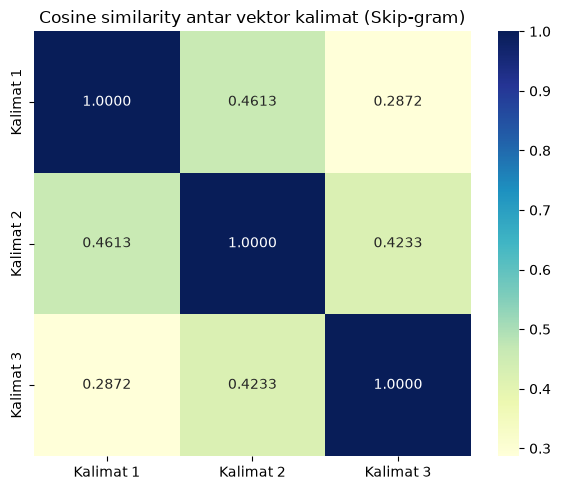

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from numpy.linalg import norm

%matplotlib inline

vec = np.array([sentence_vector(t, model_skipgram) for t in tokenized_kalimat])
sim = (vec @ vec.T) / np.outer(norm(vec, axis=1), norm(vec, axis=1))

print("=" * 72)
print("HASIL C : Cosine similarity antar kalimat")
print("=" * 72)
df_sim = pd.DataFrame(sim, index=[f"Kalimat {i+1}" for i in range(3)],
                      columns=[f"Kalimat {i+1}" for i in range(3)])
print(df_sim.round(4).to_string())

pasangan = [(0, 1), (0, 2), (1, 2)]
urut = sorted(pasangan, key=lambda p: sim[p[0], p[1]], reverse=True)
print("\nPeringkat pasangan paling mirip:")
for rank, (a, b) in enumerate(urut, 1):
    print(f"  {rank}. Kalimat {a+1} & Kalimat {b+1}: {sim[a, b]:.4f}")
a, b = urut[0]
print(f"\n-> Kalimat {a+1} & Kalimat {b+1} paling mirip (skor {sim[a, b]:.4f}).")
print("   Skor masih kecil karena model hanya dilatih dari 3 kalimat; makin banyak")
print("   data latih, similaritas antar kalimat dengan topik sama akan makin tinggi.")

plt.figure(figsize=(6, 5))
sns.heatmap(sim, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=[f"Kalimat {i+1}" for i in range(3)],
            yticklabels=[f"Kalimat {i+1}" for i in range(3)])
plt.title("Cosine similarity antar vektor kalimat (Skip-gram)")
plt.tight_layout()
plt.show()

In [7]:
print("=" * 72)
print("HASIL D : Kata paling mirip & perbandingan dengan aplikasi")
print("=" * 72)

for kata in ["indonesia", "basket", "games"]:
    if kata in model_skipgram.wv:
        mirip = model_skipgram.wv.most_similar(kata, topn=5)
        print(f"\nKata '{kata}' paling mirip dengan:")
        for kata_lain, skor in mirip:
            print(f"    {kata_lain:<20} {skor:.4f}")
    else:
        print(f"\nKata '{kata}' tidak ada di kosakata model.")

print("""
Catatan:
- Hanya ada 3 kalimat (3 dokumen), jadi Word2Vec hanya belajar dari sedikit konteks ->
  similaritas di atas masih rapuh dan hanya ilustrasi cara kerja.
- Aplikasi yang di-deploy melatih Word2Vec dari 160 dokumen berita (225 token/dokumen,
  6361 kata kosakata, vector_size=100) sehingga similaritasnya jauh lebih stabil.
- Arsitektur yang dipakai sama: Skip-gram (sg=1), beda skala data saja.
""")

HASIL D : Kata paling mirip & perbandingan dengan aplikasi

Kata 'indonesia' paling mirip dengan:
    perempatfinal        0.6387
    gagal                0.4455
    akan                 0.4251
    kegagalan            0.2899
    roster               0.2378

Kata 'basket' paling mirip dengan:
    di                   0.6104
    dan                  0.4895
    merilis              0.4489
    david                0.3767
    berlaga              0.3461

Kata 'games' paling mirip dengan:
    david                0.6485
    pelatih              0.5968
    berlaga              0.4427
    melaju               0.4340
    asian                0.4241

Catatan:
- Hanya ada 3 kalimat (3 dokumen), jadi Word2Vec hanya belajar dari sedikit konteks ->
  similaritas di atas masih rapuh dan hanya ilustrasi cara kerja.
- Aplikasi yang di-deploy melatih Word2Vec dari 160 dokumen berita (225 token/dokumen,
  6361 kata kosakata, vector_size=100) sehingga similaritasnya jauh lebih stabil.
- Arsitektur yang d